# # 대학생 중도탈락 예측 모델링 (XGBoost)
- **목표**: XGBoost와 하이퍼파라미터 튜닝을 통한 고성능 이탈 예측 분류기 구축
- **담당**: XGBoost 모델링 및 성능 평가

# Baseline Modeling (XGBoost)

튜닝의 주 기준: **F1-score**

반드시 별도로 확인: **Dropout Recall**

추가적인 모델 변별력 확인: **ROC-AUC**

하이퍼파라미터 튜닝
   - RandomizedSearchCV 사용
   - 탐색 방법: Randomized Search
   - CV 방법: Stratified K-Fold
   - K = 5
   - Train 데이터 안에서만 CV를 수행
   - Validation과 Test 데이터는 CV에 사용하지 않는다.
   - RandomizedSearchCV의 scoring은 F1-score를 사용한다.
   - 즉, 여러 하이퍼파라미터 조합 중 CV 평균 F1이 가장 높은 조합을 최적 파라미터로 선택한다.

In [20]:
import matplotlib.pyplot as plt

# 윈도우 기본 한글 폰트(맑은 고딕) 설정 및 마이너스 기호 깨짐 방지
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

# Baseline XGBoost

#### X(학생 정보) → Dropout 여부(Y)

# 핵심 가설
- 학생의 학업 성취도, 재정 상태, 등록 관련 정보 및 개인적 특성은 중도탈락 여부와 관련이 있으며, 이를 종합적으로 활용하면 중도탈락 학생을 사전에 식별할 수 있다.

### 학생의 학업·재정·인구통계학적 특성을 활용하여 중도탈락 가능성을 예측하고, 모델의 성능을 평가함으로써 중도탈락 학생을 사전에 식별할 수 있는 가능성을 확인한다.  
### XGBoost의 Feature Importance를 통해 어떤 학생 특성이 중도탈락 예측에 상대적으로 중요한 정보를 제공하는지 분석한다.

① 중도탈락을 예측할 수 있는가?  
② 실제 중도탈락 학생을 얼마나 잘 찾아낼 수 있는가?  
③ 어떤 변수들이 예측에 중요한 정보를 제공하는가?

scale_pos_weight = 2.1150

Baseline XGBoost 학습 시작...
Baseline 학습 완료!

[Baseline XGBoost - Feature Importance TOP 10]
                                 Feature  Importance
                 num__sem2_approval_rate    0.164985
       cat__Father_education_level_미상·기타    0.063660
         remainder__financial_risk_score    0.048276
      remainder__Tuition fees up to date    0.045401
                 cat__Major_field_예술·디자인    0.028179
num__Curricular units 1st sem (enrolled)    0.023097
                     cat__Major_field_사회    0.021388
          cat__Father_education_level_대학    0.021288
                  cat__Major_field_인문·사회    0.020770
    remainder__Educational special needs    0.020672

[Baseline XGBoost - Validation 성능]
Accuracy       : 0.8531
Precision      : 0.7508
Dropout Recall : 0.8140
F1-score       : 0.7811
ROC-AUC        : 0.9162

[Classification Report]
              precision    recall  f1-score   support

 Non-Dropout       0.91      0.87      0.89       600
     Dropo

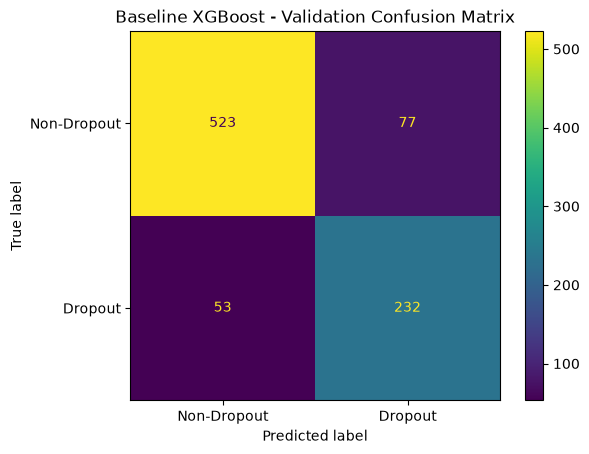


[Baseline XGBoost - Test 최종 성능]
Accuracy       : 0.8768
Precision      : 0.8159
Dropout Recall : 0.7958
F1-score       : 0.8057
ROC-AUC        : 0.9149

[Classification Report]
              precision    recall  f1-score   support

 Non-Dropout       0.90      0.92      0.91       601
     Dropout       0.82      0.80      0.81       284

    accuracy                           0.88       885
   macro avg       0.86      0.86      0.86       885
weighted avg       0.88      0.88      0.88       885


[Test Confusion Matrix]
[[550  51]
 [ 58 226]]

구성:
TN (실제 0 → 예측 0) : 550
FP (실제 0 → 예측 1) : 51
FN (실제 1 → 예측 0) : 58
TP (실제 1 → 예측 1) : 226


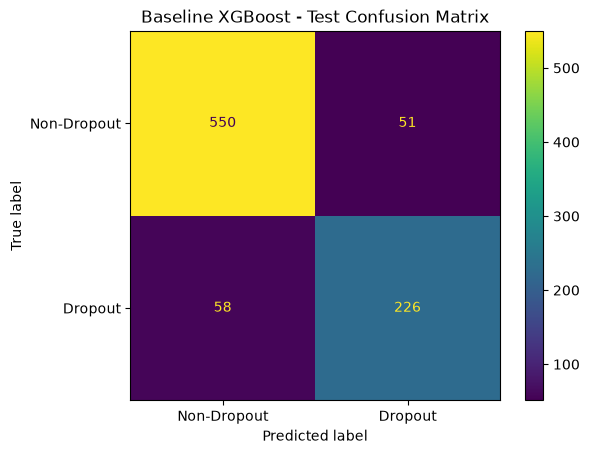


[Baseline 최종 결과 요약]
           Model  Accuracy  Precision  Dropout Recall  F1-score  ROC-AUC
Baseline XGBoost  0.876836   0.815884        0.795775  0.805704 0.914942


In [17]:
import pandas as pd
import numpy as np

from xgboost import XGBClassifier

from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt


# =====================================================================
# [1단계] 데이터 불러오기
# =====================================================================
# 전처리가 끝난 Train / Validation / Test 데이터를 불러옵니다.
#
# Train      → 모델 학습
# Validation → 모델의 중간 성능 확인
# Test       → 최종 성능 평가
# =====================================================================

train_df = pd.read_csv('../data/processed/train.csv')
val_df = pd.read_csv('../data/processed/val.csv')
test_df = pd.read_csv('../data/processed/test.csv')


# =====================================================================
# [2단계] X와 y 분리
# =====================================================================

X_train = train_df.drop('target', axis=1)
y_train = train_df['target']

X_val = val_df.drop('target', axis=1)
y_val = val_df['target']

X_test = test_df.drop('target', axis=1)
y_test = test_df['target']


# =====================================================================
# [3단계] 클래스 불균형 가중치 계산
# =====================================================================
# 0 클래스와 1 클래스의 데이터 개수를 확인합니다.
#
# 현재 프로젝트에서는
# 0 = Non-Dropout
# 1 = Dropout
#
# scale_pos_weight는 상대적으로 적은 클래스인 1(Dropout)을
# 모델이 더 중요하게 학습하도록 만들어줍니다.
#
# 공식:
#
#       0의 개수
# -------------------
#       1의 개수
# =====================================================================

weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

print(f"scale_pos_weight = {weight:.4f}")


# =====================================================================
# [4단계] Baseline XGBoost 생성
# =====================================================================

baseline_model = XGBClassifier(
    scale_pos_weight=weight,
    random_state=42
)


# =====================================================================
# [5단계] Baseline 모델 학습
# =====================================================================

print("\nBaseline XGBoost 학습 시작...")

baseline_model.fit(X_train, y_train)

print("Baseline 학습 완료!")



# =====================================================================
# [Feature Importance]
# XGBoost가 예측할 때 각 Feature(컬럼)를 얼마나 중요하게 활용했는지 확인
# =====================================================================

importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': baseline_model.feature_importances_
}).sort_values(
    by='Importance',
    ascending=False
)

print("\n" + "=" * 60)
print("[Baseline XGBoost - Feature Importance TOP 10]")
print("=" * 60)

print(importance_df.head(10).to_string(index=False))


# =====================================================================
# [6단계] Validation 데이터 예측
# =====================================================================
# predict_proba()는 각 클래스에 대한 "확률"을 반환합니다.
#
# [:, 1]
# → Dropout(1)일 확률만 가져옵니다.
#
# 예:
# 0.82 → Dropout일 확률 82%
# 0.31 → Dropout일 확률 31%
#
# Threshold 0.5를 기준으로 최종 클래스를 결정합니다.
# =====================================================================

val_proba = baseline_model.predict_proba(X_val)[:, 1]

val_pred = (val_proba >= 0.5).astype(int)


# =====================================================================
# [7단계] Validation 성능 계산
# =====================================================================

val_accuracy = accuracy_score(y_val, val_pred)

val_precision = precision_score(
    y_val,
    val_pred,
    pos_label=1
)

val_recall = recall_score(
    y_val,
    val_pred,
    pos_label=1
)

val_f1 = f1_score(
    y_val,
    val_pred,
    pos_label=1
)

val_roc_auc = roc_auc_score(
    y_val,
    val_proba
)


# =====================================================================
# [8단계] Validation 결과 출력
# =====================================================================

print("\n" + "=" * 60)
print("[Baseline XGBoost - Validation 성능]")
print("=" * 60)

print(f"Accuracy       : {val_accuracy:.4f}")
print(f"Precision      : {val_precision:.4f}")
print(f"Dropout Recall : {val_recall:.4f}")
print(f"F1-score       : {val_f1:.4f}")
print(f"ROC-AUC        : {val_roc_auc:.4f}")


# Classification Report
# → 클래스별 Precision / Recall / F1을 한 번에 확인
print("\n[Classification Report]")

print(
    classification_report(
        y_val,
        val_pred,
        target_names=['Non-Dropout', 'Dropout']
    )
)


# =====================================================================
# [9단계] Validation Confusion Matrix
# =====================================================================
# Confusion Matrix의 구조:
#
#                  예측
#             0          1
#
# 실제 0      TN         FP
# 실제 1      FN         TP
#
# FN:
# 실제 Dropout인데 Non-Dropout이라고 예측
#
# TP:
# 실제 Dropout이고 Dropout이라고 정확히 예측
#
# 우리 프로젝트에서는 FN을 특히 중요하게 봅니다.
# =====================================================================

val_cm = confusion_matrix(y_val, val_pred)

print("\n[Validation Confusion Matrix]")
print(val_cm)

print("\n구성:")
print(f"TN (실제 0 → 예측 0) : {val_cm[0, 0]}")
print(f"FP (실제 0 → 예측 1) : {val_cm[0, 1]}")
print(f"FN (실제 1 → 예측 0) : {val_cm[1, 0]}")
print(f"TP (실제 1 → 예측 1) : {val_cm[1, 1]}")


# Confusion Matrix 시각화
ConfusionMatrixDisplay(
    confusion_matrix=val_cm,
    display_labels=['Non-Dropout', 'Dropout']
).plot()

plt.title('Baseline XGBoost - Validation Confusion Matrix')
plt.show()


# =====================================================================
# [10단계] Test 데이터 예측
# =====================================================================
# Test는 최종 평가용입니다.
#
# 여기서는 Threshold를 다시 조정하지 않습니다.
# Validation과 동일하게 0.5를 사용합니다.
# =====================================================================

test_proba = baseline_model.predict_proba(X_test)[:, 1]

test_pred = (test_proba >= 0.5).astype(int)


# =====================================================================
# [11단계] Test 성능 계산
# =====================================================================

test_accuracy = accuracy_score(y_test, test_pred)

test_precision = precision_score(
    y_test,
    test_pred,
    pos_label=1
)

test_recall = recall_score(
    y_test,
    test_pred,
    pos_label=1
)

test_f1 = f1_score(
    y_test,
    test_pred,
    pos_label=1
)

test_roc_auc = roc_auc_score(
    y_test,
    test_proba
)


# =====================================================================
# [12단계] Baseline 최종 Test 결과
# =====================================================================

print("\n" + "=" * 60)
print("[Baseline XGBoost - Test 최종 성능]")
print("=" * 60)

print(f"Accuracy       : {test_accuracy:.4f}")
print(f"Precision      : {test_precision:.4f}")
print(f"Dropout Recall : {test_recall:.4f}")
print(f"F1-score       : {test_f1:.4f}")
print(f"ROC-AUC        : {test_roc_auc:.4f}")


print("\n[Classification Report]")

print(
    classification_report(
        y_test,
        test_pred,
        target_names=['Non-Dropout', 'Dropout']
    )
)


# =====================================================================
# [13단계] Test Confusion Matrix
# =====================================================================

test_cm = confusion_matrix(y_test, test_pred)

print("\n[Test Confusion Matrix]")
print(test_cm)

print("\n구성:")
print(f"TN (실제 0 → 예측 0) : {test_cm[0, 0]}")
print(f"FP (실제 0 → 예측 1) : {test_cm[0, 1]}")
print(f"FN (실제 1 → 예측 0) : {test_cm[1, 0]}")
print(f"TP (실제 1 → 예측 1) : {test_cm[1, 1]}")


ConfusionMatrixDisplay(
    confusion_matrix=test_cm,
    display_labels=['Non-Dropout', 'Dropout']
).plot()

plt.title('Baseline XGBoost - Test Confusion Matrix')
plt.show()


# =====================================================================
# [14단계] Baseline 최종 결과를 DataFrame으로 저장
# =====================================================================
# 나중에 Tuned XGBoost와 비교하기 위한 표입니다.
# =====================================================================

baseline_result = pd.DataFrame({
    'Model': ['Baseline XGBoost'],
    'Accuracy': [test_accuracy],
    'Precision': [test_precision],
    'Dropout Recall': [test_recall],
    'F1-score': [test_f1],
    'ROC-AUC': [test_roc_auc]
})

print("\n" + "=" * 60)
print("[Baseline 최종 결과 요약]")
print("=" * 60)

print(baseline_result.to_string(index=False))

**BaseLine**  
Accuracy       : 0.8768  
Precision      : 0.8159  
Dropout Recall : 0.7958  
F1-score       : 0.8057  
ROC-AUC        : 0.9149  

=> "학생 정보를 이용한 중도탈락 예측이 가능하다는 가설을 지지한다."

# 하이퍼파라미터 튜닝 XGBoost

scale_pos_weight = 2.1150

XGBoost 하이퍼파라미터 튜닝 시작...
튜닝 완료!

[최적 하이퍼파라미터]
{'subsample': 0.9, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.01}

최고 CV 평균 F1-score : 0.7881

[Tuned XGBoost - Feature Importance TOP 10]
                                 Feature  Importance
                 num__sem2_approval_rate    0.226252
         remainder__financial_risk_score    0.040785
      remainder__Tuition fees up to date    0.034552
num__Curricular units 1st sem (enrolled)    0.026921
                 cat__Major_field_예술·디자인    0.026678
                 num__sem1_approval_rate    0.023887
       cat__Father_education_level_미상·기타    0.018174
                     cat__Major_field_교육    0.016747
     cat__Father_education_level_중등교육 이하    0.015944
                     cat__Major_field_사회    0.015727

[RandomizedSearchCV 하이퍼파라미터 탐색 결과 TOP 10]
 rank_test_score  mean_test_score  std_test_score  param_n_estimators  param_max_depth  param_learning_rate  param_subsample
               1        

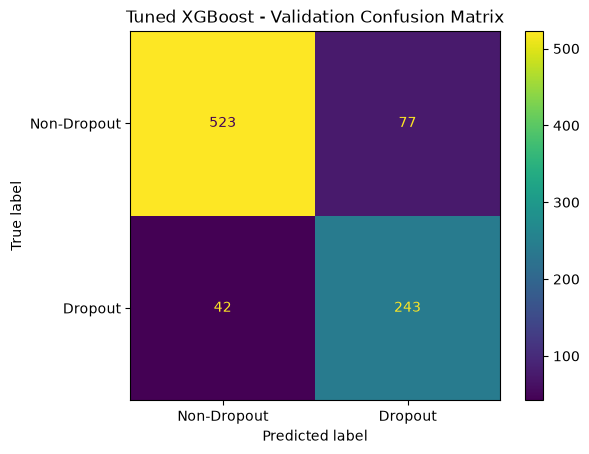


[Tuned XGBoost - Test 최종 성능]
Accuracy       : 0.8780
Precision      : 0.8034
Dropout Recall : 0.8204
F1-score       : 0.8118
ROC-AUC        : 0.9320

[Classification Report]
              precision    recall  f1-score   support

 Non-Dropout       0.91      0.91      0.91       601
     Dropout       0.80      0.82      0.81       284

    accuracy                           0.88       885
   macro avg       0.86      0.86      0.86       885
weighted avg       0.88      0.88      0.88       885


[Test Confusion Matrix]
[[544  57]
 [ 51 233]]

구성:
TN (실제 0 → 예측 0) : 544
FP (실제 0 → 예측 1) : 57
FN (실제 1 → 예측 0) : 51
TP (실제 1 → 예측 1) : 233


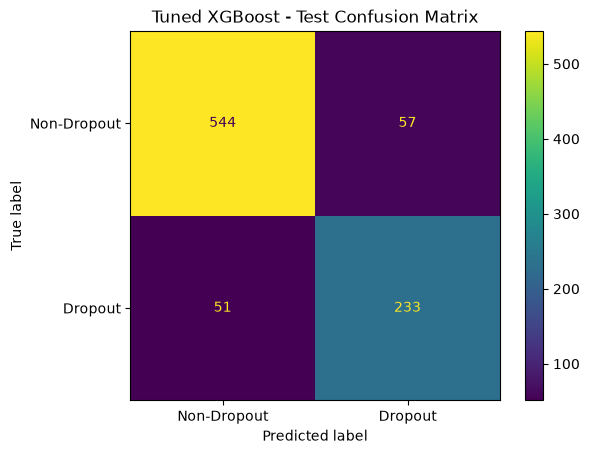


[Tuned XGBoost 최종 결과 요약]
        Model  Accuracy  Precision  Dropout Recall  F1-score  ROC-AUC
Tuned XGBoost  0.877966   0.803448        0.820423  0.811847 0.932021


In [1]:
import pandas as pd
import numpy as np

from xgboost import XGBClassifier

from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold
)

import matplotlib.pyplot as plt


# =====================================================================
# [1단계] 데이터 불러오기
# =====================================================================
# 전처리가 끝난 Train / Validation / Test 데이터를 불러옵니다.
#
# Train      → RandomizedSearchCV를 통한 모델 학습 및 하이퍼파라미터 탐색
# Validation → 튜닝된 모델의 중간 성능 확인
# Test       → 최종 성능 평가
# =====================================================================

train_df = pd.read_csv('../data/processed/train.csv')
val_df = pd.read_csv('../data/processed/val.csv')
test_df = pd.read_csv('../data/processed/test.csv')


# =====================================================================
# [2단계] X와 y 분리
# =====================================================================
# X → 모델이 학습할 Feature(설명변수)
# y → 모델이 예측할 Target(정답)
#
# 현재 프로젝트:
# 0 = Non-Dropout
# 1 = Dropout
# =====================================================================

X_train = train_df.drop('target', axis=1)
y_train = train_df['target']

X_val = val_df.drop('target', axis=1)
y_val = val_df['target']

X_test = test_df.drop('target', axis=1)
y_test = test_df['target']


# =====================================================================
# [3단계] 클래스 불균형 가중치 계산
# =====================================================================
# Dropout(1)과 Non-Dropout(0)의 데이터 수가 다르기 때문에
# Dropout 클래스가 학습 과정에서 상대적으로 더 중요하게 반영되도록
# scale_pos_weight를 계산합니다.
#
# 공식:
#
#       Non-Dropout(0) 개수
# ------------------------------
#       Dropout(1) 개수
#
# 예를 들어
# 0이 600명이고 1이 284명이면
#
# 600 / 284 ≈ 2.11
#
# 따라서 Dropout을 틀렸을 때 더 큰 가중치를 주게 됩니다.
# =====================================================================

weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

print(f"scale_pos_weight = {weight:.4f}")


# =====================================================================
# [4단계] XGBoost 기본 모델 생성
# =====================================================================
# 여기서는 하이퍼파라미터를 하나하나 최적화하지 않고,
# RandomizedSearchCV가 아래 param_dist에 있는 후보들을
# 조합하여 최적의 설정을 찾도록 합니다.
# =====================================================================

xgb_model = XGBClassifier(
    scale_pos_weight=weight,
    random_state=42
)


# =====================================================================
# [5단계] 하이퍼파라미터 후보 설정
# =====================================================================
# 하이퍼파라미터:
#
# n_estimators
# → 생성할 결정트리의 개수
#
# max_depth
# → 각각의 결정트리가 가질 수 있는 최대 깊이
#
# learning_rate
# → 각각의 트리가 기존 모델을 얼마나 보완할지 결정하는 학습률
#
# subsample
# → 각 트리를 학습할 때 사용할 데이터의 비율
#
# RandomizedSearchCV는 아래 후보들 중에서
# 무작위로 조합을 선택하여 성능을 비교합니다.
# =====================================================================

param_dist = {

    'n_estimators': [
        100,
        200,
        300
    ],

    'max_depth': [
        3,
        5,
        7
    ],

    'learning_rate': [
        0.01,
        0.05,
        0.1
    ],

    'subsample': [
        0.8,
        0.9,
        1.0
    ]
}


# =====================================================================
# [6단계] Stratified K-Fold 설정
# =====================================================================
# Train 데이터를 5개의 Fold로 나누어 교차검증합니다.
#
# 일반 K-Fold와 달리 Stratified K-Fold는
# 각 Fold마다 Dropout / Non-Dropout 비율이
# 최대한 비슷하게 유지되도록 데이터를 나눕니다.
#
# n_splits=5
# → 5개의 Fold 사용
#
# shuffle=True
# → 데이터를 섞은 뒤 Fold 생성
#
# random_state=42
# → 매번 동일한 방식으로 나누어지도록 설정
# =====================================================================

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# =====================================================================
# [7단계] RandomizedSearchCV 설정
# =====================================================================
# RandomizedSearchCV는
#
# ① 하이퍼파라미터 후보 조합을 무작위로 선택
# ② 각 조합에 대해 5-Fold 교차검증
# ③ 각 조합의 평균 F1-score 계산
# ④ 가장 높은 F1-score를 기록한 조합 선택
#
# scoring='f1'
# → 우리가 정한 튜닝의 최우선 기준인 F1-score를 사용합니다.
#
# n_iter=30
# → 전체 후보 조합 중 30개의 조합을 무작위로 테스트합니다.
# =====================================================================

random_search = RandomizedSearchCV(

    estimator=xgb_model,

    param_distributions=param_dist,

    n_iter=30,

    scoring='f1',

    cv=skf,

    random_state=42,

    n_jobs=-1,

    return_train_score=True
)


# =====================================================================
# [8단계] 하이퍼파라미터 튜닝 및 모델 학습
# =====================================================================

print("\nXGBoost 하이퍼파라미터 튜닝 시작...")

random_search.fit(
    X_train,
    y_train
)

print("튜닝 완료!")


# =====================================================================
# [9단계] 최적 하이퍼파라미터 확인
# =====================================================================
# best_params_
# → CV에서 가장 높은 F1-score를 기록한 하이퍼파라미터 조합
#
# best_score_
# → 해당 조합의 평균 CV F1-score
# =====================================================================

print("\n" + "=" * 60)
print("[최적 하이퍼파라미터]")
print("=" * 60)

print(random_search.best_params_)

print(
    f"\n최고 CV 평균 F1-score : "
    f"{random_search.best_score_:.4f}"
)


# =====================================================================
# [10단계] 최적 모델 가져오기
# =====================================================================
# RandomizedSearchCV가 여러 하이퍼파라미터 조합을 비교한 후
# 가장 높은 F1-score를 기록한 모델을 가져옵니다.
#
# ★ 매우 중요 ★
#
# 앞으로 Validation / Test 평가와 Feature Importance 분석에는
# 반드시 이 best_model을 사용합니다.
# =====================================================================

best_model = random_search.best_estimator_


# =====================================================================
# [11단계] Tuned XGBoost Feature Importance
# =====================================================================
# ★ 중요 ★
#
# 여기서는 Baseline 모델이 아니라
# RandomizedSearchCV가 선택한 "최적 Tuned 모델"인
# best_model의 Feature Importance를 사용합니다.
#
# Importance가 높을수록
# XGBoost가 중도탈락 여부를 예측하는 과정에서
# 해당 Feature를 상대적으로 중요하게 활용했다는 의미입니다.
#
# 단,
# Feature Importance가 높다고 해서
# 해당 변수가 중도탈락의 "원인"이라는 뜻은 아닙니다.
# =====================================================================

importance_df = pd.DataFrame({

    'Feature': X_train.columns,

    'Importance': best_model.feature_importances_

}).sort_values(

    by='Importance',

    ascending=False
)


print("\n" + "=" * 60)
print("[Tuned XGBoost - Feature Importance TOP 10]")
print("=" * 60)

print(
    importance_df
    .head(10)
    .to_string(index=False)
)


# =====================================================================
# [12단계] RandomizedSearchCV 하이퍼파라미터 탐색 결과 확인
# =====================================================================
# 모든 테스트 조합 중 성능이 좋았던 상위 10개 조합을 확인합니다.
#
# mean_test_score
# → 5-Fold CV의 평균 F1-score
#
# std_test_score
# → Fold마다 F1-score가 얼마나 차이났는지 나타내는 값
#
# rank_test_score
# → 전체 조합 중 성능 순위
# =====================================================================

cv_results = pd.DataFrame(
    random_search.cv_results_
)

cv_results = cv_results.sort_values(
    by='rank_test_score'
)


print("\n" + "=" * 60)
print("[RandomizedSearchCV 하이퍼파라미터 탐색 결과 TOP 10]")
print("=" * 60)

print(
    cv_results[
        [
            'rank_test_score',
            'mean_test_score',
            'std_test_score',
            'param_n_estimators',
            'param_max_depth',
            'param_learning_rate',
            'param_subsample'
        ]
    ]
    .head(10)
    .to_string(index=False)
)


# =====================================================================
# [13단계] Validation 데이터 예측
# =====================================================================
# 튜닝이 완료된 best_model을 사용하여
# Validation 데이터의 Dropout 확률을 예측합니다.
#
# [:, 1]
# → Dropout(1)일 확률만 가져옵니다.
#
# Threshold 0.5
# → Dropout 확률이 50% 이상이면 1(Dropout)
# → 50% 미만이면 0(Non-Dropout)
# =====================================================================

val_proba = best_model.predict_proba(
    X_val
)[:, 1]

val_pred = (
    val_proba >= 0.5
).astype(int)


# =====================================================================
# [14단계] Validation 성능 계산
# =====================================================================

val_accuracy = accuracy_score(
    y_val,
    val_pred
)

val_precision = precision_score(
    y_val,
    val_pred,
    pos_label=1
)

val_recall = recall_score(
    y_val,
    val_pred,
    pos_label=1
)

val_f1 = f1_score(
    y_val,
    val_pred,
    pos_label=1
)

val_roc_auc = roc_auc_score(
    y_val,
    val_proba
)


# =====================================================================
# [15단계] Validation 결과 출력
# =====================================================================

print("\n" + "=" * 60)
print("[Tuned XGBoost - Validation 성능]")
print("=" * 60)

print(
    f"Accuracy       : {val_accuracy:.4f}"
)

print(
    f"Precision      : {val_precision:.4f}"
)

print(
    f"Dropout Recall : {val_recall:.4f}"
)

print(
    f"F1-score       : {val_f1:.4f}"
)

print(
    f"ROC-AUC        : {val_roc_auc:.4f}"
)


print("\n[Classification Report]")

print(
    classification_report(
        y_val,
        val_pred,
        target_names=[
            'Non-Dropout',
            'Dropout'
        ]
    )
)


# =====================================================================
# [16단계] Validation Confusion Matrix
# =====================================================================

val_cm = confusion_matrix(
    y_val,
    val_pred
)

print("\n[Validation Confusion Matrix]")

print(val_cm)

print("\n구성:")

print(
    f"TN (실제 0 → 예측 0) : "
    f"{val_cm[0, 0]}"
)

print(
    f"FP (실제 0 → 예측 1) : "
    f"{val_cm[0, 1]}"
)

print(
    f"FN (실제 1 → 예측 0) : "
    f"{val_cm[1, 0]}"
)

print(
    f"TP (실제 1 → 예측 1) : "
    f"{val_cm[1, 1]}"
)


# Validation Confusion Matrix 시각화

ConfusionMatrixDisplay(
    confusion_matrix=val_cm,
    display_labels=[
        'Non-Dropout',
        'Dropout'
    ]
).plot()

plt.title(
    'Tuned XGBoost - Validation Confusion Matrix'
)

plt.show()


# =====================================================================
# [17단계] Test 데이터 예측
# =====================================================================
# Test 데이터는 최종 성능 평가에만 사용합니다.
#
# Validation에서 사용한 것과 동일하게
# Threshold 0.5를 사용합니다.
#
# Test 결과는 최종 모델의 일반화 성능을 확인하기 위한 결과입니다.
# =====================================================================

test_proba = best_model.predict_proba(
    X_test
)[:, 1]

test_pred = (
    test_proba >= 0.5
).astype(int)


# =====================================================================
# [18단계] Test 성능 계산
# =====================================================================

test_accuracy = accuracy_score(
    y_test,
    test_pred
)

test_precision = precision_score(
    y_test,
    test_pred,
    pos_label=1
)

test_recall = recall_score(
    y_test,
    test_pred,
    pos_label=1
)

test_f1 = f1_score(
    y_test,
    test_pred,
    pos_label=1
)

test_roc_auc = roc_auc_score(
    y_test,
    test_proba
)


# =====================================================================
# [19단계] Tuned XGBoost 최종 Test 결과
# =====================================================================

print("\n" + "=" * 60)
print("[Tuned XGBoost - Test 최종 성능]")
print("=" * 60)

print(
    f"Accuracy       : {test_accuracy:.4f}"
)

print(
    f"Precision      : {test_precision:.4f}"
)

print(
    f"Dropout Recall : {test_recall:.4f}"
)

print(
    f"F1-score       : {test_f1:.4f}"
)

print(
    f"ROC-AUC        : {test_roc_auc:.4f}"
)


print("\n[Classification Report]")

print(
    classification_report(
        y_test,
        test_pred,
        target_names=[
            'Non-Dropout',
            'Dropout'
        ]
    )
)


# =====================================================================
# [20단계] Test Confusion Matrix
# =====================================================================

test_cm = confusion_matrix(
    y_test,
    test_pred
)

print("\n[Test Confusion Matrix]")

print(test_cm)

print("\n구성:")

print(
    f"TN (실제 0 → 예측 0) : "
    f"{test_cm[0, 0]}"
)

print(
    f"FP (실제 0 → 예측 1) : "
    f"{test_cm[0, 1]}"
)

print(
    f"FN (실제 1 → 예측 0) : "
    f"{test_cm[1, 0]}"
)

print(
    f"TP (실제 1 → 예측 1) : "
    f"{test_cm[1, 1]}"
)


# Test Confusion Matrix 시각화

ConfusionMatrixDisplay(
    confusion_matrix=test_cm,
    display_labels=[
        'Non-Dropout',
        'Dropout'
    ]
).plot()

plt.title(
    'Tuned XGBoost - Test Confusion Matrix'
)

plt.show()


# =====================================================================
# [21단계] Tuned XGBoost 최종 결과 요약
# =====================================================================
# Baseline XGBoost와 비교하기 위한 최종 결과표입니다.
# =====================================================================

tuned_result = pd.DataFrame({

    'Model': [
        'Tuned XGBoost'
    ],

    'Accuracy': [
        test_accuracy
    ],

    'Precision': [
        test_precision
    ],

    'Dropout Recall': [
        test_recall
    ],

    'F1-score': [
        test_f1
    ],

    'ROC-AUC': [
        test_roc_auc
    ]
})


print("\n" + "=" * 60)
print("[Tuned XGBoost 최종 결과 요약]")
print("=" * 60)

print(
    tuned_result.to_string(
        index=False
    )
)

하이퍼파라미터	최적값	의미
n_estimators	300	결정트리를 300개 사용
max_depth	5	각 트리의 최대 깊이를 5로 제한
learning_rate	0.01	한 번에 조금씩 학습
subsample	0.9	각 트리를 학습할 때 데이터의 90% 사용

하이퍼파라미터	  최적값	  의미  
n_estimators	300	       결정트리를 300개 사용
max_depth     	5	       각 트리의 최대 깊이를 5로 제한
learning_rate	0.01	   한 번에 조금씩 학습
subsample	    0.9	       각 트리를 학습할 때 데이터의 90% 사용

# ===========================
# 2차 튜닝 ===================
# ===========================

RandomizedSearchCV의 scoring → recall  
최종 조합 선택 기준 → Recall → F1 → ROC-AUC 순서   
F1 >= 0.8  

그리고 기존처럼 n_iter = 10, 20, 30, 40, 50, 60, 70, 81을 전부 돌리고, 각 모델에 대해 Threshold 후보도 여러 개 시험  

============================================================================

# scoring='recall' + f1 >= 0.85

scale_pos_weight = 2.1150

XGBoost 하이퍼파라미터 + Threshold 탐색 시작

최종 선택 기준:
① Validation F1 >= 0.80
② 그중 Dropout Recall 최대
③ Recall 동률 → F1-score
④ F1 동률 → ROC-AUC

----------------------------------------------------------------------
[RandomizedSearchCV] n_iter = 10
----------------------------------------------------------------------
최고 CV 평균 Recall : 0.8216
최적 하이퍼파라미터 : {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.01}

[Validation 최고 성능]
(F1 >= 0.80 조건 만족 후보 중 선택)
Threshold      : 0.59
Recall         : 0.8000
F1-score       : 0.8000
Precision      : 0.8000
Accuracy       : 0.8712
ROC-AUC        : 0.9153

----------------------------------------------------------------------
[RandomizedSearchCV] n_iter = 20
----------------------------------------------------------------------
최고 CV 평균 Recall : 0.8216
최적 하이퍼파라미터 : {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.01}

[Validation 최고 성능]
(F1 >= 0.80 조건 만족 후보 중 선택)
Threshold      : 0

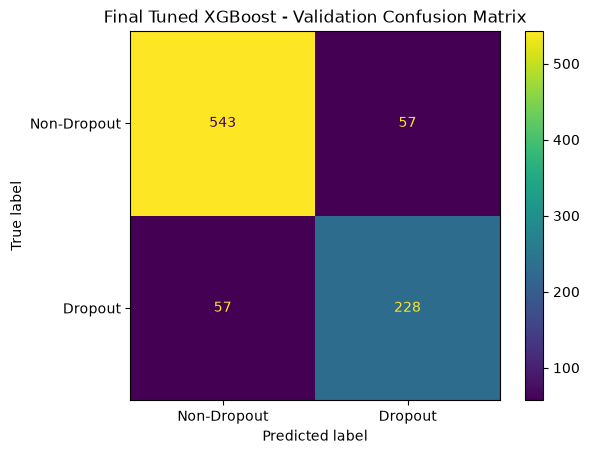


[n_iter별 최고 Validation 성능]
 n_iter  Threshold  Validation_Recall  Validation_F1  Validation_Precision  Validation_Accuracy  Validation_ROC_AUC
     10       0.59                0.8            0.8                   0.8             0.871186            0.915313
     20       0.59                0.8            0.8                   0.8             0.871186            0.915313
     30       0.59                0.8            0.8                   0.8             0.871186            0.915313
     40       0.59                0.8            0.8                   0.8             0.871186            0.915313
     50       0.59                0.8            0.8                   0.8             0.871186            0.915313
     60       0.59                0.8            0.8                   0.8             0.871186            0.915313
     70       0.59                0.8            0.8                   0.8             0.871186            0.915313


In [6]:
import pandas as pd
import numpy as np

from xgboost import XGBClassifier

from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

import matplotlib.pyplot as plt


# =====================================================================
# [1단계] 데이터 불러오기
# =====================================================================

train_df = pd.read_csv('../data/processed/train.csv')
val_df = pd.read_csv('../data/processed/val.csv')
test_df = pd.read_csv('../data/processed/test.csv')


# =====================================================================
# [2단계] X와 y 분리
# =====================================================================

X_train = train_df.drop('target', axis=1)
y_train = train_df['target']

X_val = val_df.drop('target', axis=1)
y_val = val_df['target']

X_test = test_df.drop('target', axis=1)
y_test = test_df['target']


# =====================================================================
# [3단계] 클래스 불균형 가중치 계산
# =====================================================================

weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

print(f"scale_pos_weight = {weight:.4f}")


# =====================================================================
# [4단계] XGBoost 기본 모델 생성
# =====================================================================

xgb_model = XGBClassifier(
    scale_pos_weight=weight,
    random_state=42
)


# =====================================================================
# [5단계] 하이퍼파라미터 후보 설정
# =====================================================================

param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 0.9, 1.0]
}


# =====================================================================
# [6단계] Stratified K-Fold 설정
# =====================================================================

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# =====================================================================
# [7단계] n_iter 후보 설정
# =====================================================================
# 전체 하이퍼파라미터 조합은 81개입니다.
#
# n_iter가 클수록 더 많은 하이퍼파라미터 조합을 탐색합니다.
# =====================================================================

n_iter_list = [10, 20, 30, 40, 50, 60, 70, 81]


# =====================================================================
# [8단계] Threshold 후보 설정
# =====================================================================
# 0.30 ~ 0.80까지 0.01 간격으로 모두 테스트합니다.
# =====================================================================

threshold_list = np.arange(0.30, 0.81, 0.01)


# =====================================================================
# ★ [추가] F1 최소 기준 설정
# =====================================================================
# Recall을 최대화하되 F1이 지나치게 낮아지는 것을 방지하기 위해
# Validation F1-score가 0.8 이상인 후보만 최종 후보로 인정합니다.
#
# 즉,
#
# F1 < 0.8  → 탈락
# F1 >= 0.8 → 후보 유지
#
# 이후 남은 후보 중에서 Recall이 가장 높은 모델을 선택합니다.
# =====================================================================

MIN_F1 = 0.8


# =====================================================================
# [9단계] 전체 탐색 결과 저장용
# =====================================================================

all_results = []


print("\n" + "=" * 70)
print("XGBoost 하이퍼파라미터 + Threshold 탐색 시작")
print("=" * 70)

print(f"\n최종 선택 기준:")
print(f"① Validation F1 >= {MIN_F1:.2f}")
print("② 그중 Dropout Recall 최대")
print("③ Recall 동률 → F1-score")
print("④ F1 동률 → ROC-AUC")


# =====================================================================
# [10단계] n_iter별 RandomizedSearchCV
# =====================================================================

for n_iter in n_iter_list:

    print("\n" + "-" * 70)
    print(f"[RandomizedSearchCV] n_iter = {n_iter}")
    print("-" * 70)


    random_search = RandomizedSearchCV(
        estimator=xgb_model,
        param_distributions=param_dist,

        # 이번 탐색에서 시험할 하이퍼파라미터 조합 수
        n_iter=n_iter,

        # ★ 하이퍼파라미터 탐색 자체는 Recall 기준
        scoring='recall',

        # Stratified K-Fold
        cv=skf,

        random_state=42,
        n_jobs=-1
    )


    # ---------------------------------------------------------------
    # 모델 학습 및 하이퍼파라미터 탐색
    # ---------------------------------------------------------------

    random_search.fit(
        X_train,
        y_train
    )


    best_model = random_search.best_estimator_


    print(
        f"최고 CV 평균 Recall : "
        f"{random_search.best_score_:.4f}"
    )

    print(
        f"최적 하이퍼파라미터 : "
        f"{random_search.best_params_}"
    )


    # ---------------------------------------------------------------
    # Validation에서 Dropout 확률 계산
    # ---------------------------------------------------------------

    val_proba = best_model.predict_proba(
        X_val
    )[:, 1]


    # ROC-AUC는 Threshold와 관계없이
    # 해당 모델의 전체적인 변별력을 확인하는 지표입니다.
    val_roc_auc = roc_auc_score(
        y_val,
        val_proba
    )


    # ===============================================================
    # [11단계] Threshold 여러 개 시험
    # ===============================================================

    best_threshold_result = None


    for threshold in threshold_list:


        # Threshold를 기준으로 0 / 1 결정
        val_pred = (
            val_proba >= threshold
        ).astype(int)


        # -----------------------------------------------------------
        # 평가 지표 계산
        # -----------------------------------------------------------

        val_accuracy = accuracy_score(
            y_val,
            val_pred
        )

        val_precision = precision_score(
            y_val,
            val_pred,
            pos_label=1,
            zero_division=0
        )

        val_recall = recall_score(
            y_val,
            val_pred,
            pos_label=1,
            zero_division=0
        )

        val_f1 = f1_score(
            y_val,
            val_pred,
            pos_label=1,
            zero_division=0
        )


        # ===========================================================
        # ★ [핵심 수정]
        #
        # F1이 0.85보다 낮으면 최종 후보에서 제외합니다.
        # ===========================================================

        if val_f1 < MIN_F1:
            continue


        # ===========================================================
        # F1 >= 0.85인 후보들만 남긴 뒤
        #
        # ① Recall
        # ② F1
        # ③ ROC-AUC
        #
        # 순서로 비교합니다.
        # ===========================================================

        current_score = (
            val_recall,
            val_f1,
            val_roc_auc
        )


        if (
            best_threshold_result is None
            or current_score
            > best_threshold_result['score']
        ):

            best_threshold_result = {

                'n_iter':
                    n_iter,

                'Threshold':
                    threshold,

                'CV_Recall':
                    random_search.best_score_,

                'Validation_Accuracy':
                    val_accuracy,

                'Validation_Precision':
                    val_precision,

                'Validation_Recall':
                    val_recall,

                'Validation_F1':
                    val_f1,

                'Validation_ROC_AUC':
                    val_roc_auc,

                'Best_Params':
                    random_search.best_params_,

                # 최종 비교용
                'score':
                    current_score
            }


    # ===============================================================
    # [12단계] 해당 n_iter에서 F1 >= 0.85 후보가 존재하는지 확인
    # ===============================================================

    if best_threshold_result is None:

        print(
            f"\n⚠ n_iter={n_iter}에서는 "
            f"F1 >= {MIN_F1:.2f}인 Threshold가 없습니다."
        )

    else:

        print("\n[Validation 최고 성능]")
        print(
            f"(F1 >= {MIN_F1:.2f} 조건 만족 후보 중 선택)"
        )

        print(
            f"Threshold      : "
            f"{best_threshold_result['Threshold']:.2f}"
        )

        print(
            f"Recall         : "
            f"{best_threshold_result['Validation_Recall']:.4f}"
        )

        print(
            f"F1-score       : "
            f"{best_threshold_result['Validation_F1']:.4f}"
        )

        print(
            f"Precision      : "
            f"{best_threshold_result['Validation_Precision']:.4f}"
        )

        print(
            f"Accuracy       : "
            f"{best_threshold_result['Validation_Accuracy']:.4f}"
        )

        print(
            f"ROC-AUC        : "
            f"{best_threshold_result['Validation_ROC_AUC']:.4f}"
        )


        # 전체 결과에 저장
        all_results.append(
            best_threshold_result
        )


# =====================================================================
# [13단계] 전체 n_iter + Threshold 결과 비교
# =====================================================================

results_df = pd.DataFrame(
    all_results
)


# 내부 비교용 score 컬럼 제거
if not results_df.empty:

    results_df = results_df.drop(
        columns=['score']
    )


print("\n" + "=" * 70)
print("[전체 n_iter + Threshold 조합 결과]")
print("=" * 70)


# =====================================================================
# [14단계] 최종 선택
# =====================================================================
#
# 이미 F1 >= 0.85인 후보만 all_results에 들어왔기 때문에
# 여기서는 다음 순서로 정렬합니다.
#
# ① Recall 높은 순
# ② F1 높은 순
# ③ ROC-AUC 높은 순
# =====================================================================

if results_df.empty:

    print(
        f"\n⚠ F1 >= {MIN_F1:.2f}를 만족하는 후보가 없습니다."
    )

    print(
        "MIN_F1 값을 낮추거나 "
        "하이퍼파라미터/Threshold 탐색 범위를 조정하세요."
    )

else:

    results_df = results_df.sort_values(
        by=[
            'Validation_Recall',
            'Validation_F1',
            'Validation_ROC_AUC'
        ],
        ascending=[
            False,
            False,
            False
        ]
    )


    print(
        results_df.head(20).to_string(
            index=False
        )
    )


    # ===============================================================
    # [15단계] 최종 최적 조합 선택
    # ===============================================================

    best_result = results_df.iloc[0]


    print("\n" + "=" * 70)
    print("[전체 탐색 결과 - 최적 조합]")
    print("=" * 70)


    print(
        f"F1 최소 기준        : "
        f"{MIN_F1:.2f}"
    )

    print(
        f"최적 n_iter          : "
        f"{int(best_result['n_iter'])}"
    )

    print(
        f"최적 Threshold       : "
        f"{best_result['Threshold']:.2f}"
    )

    print(
        f"Validation Recall    : "
        f"{best_result['Validation_Recall']:.4f}"
    )

    print(
        f"Validation F1-score  : "
        f"{best_result['Validation_F1']:.4f}"
    )

    print(
        f"Validation Precision  : "
        f"{best_result['Validation_Precision']:.4f}"
    )

    print(
        f"Validation Accuracy   : "
        f"{best_result['Validation_Accuracy']:.4f}"
    )

    print(
        f"Validation ROC-AUC    : "
        f"{best_result['Validation_ROC_AUC']:.4f}"
    )

    print(
        f"CV Recall             : "
        f"{best_result['CV_Recall']:.4f}"
    )

    print(
        f"최적 하이퍼파라미터   : "
        f"{best_result['Best_Params']}"
    )


    # =================================================================
    # [16단계] 최종 모델 재학습
    # =================================================================

    print("\n" + "=" * 70)
    print(
        f"[최종 XGBoost 모델 재학습] "
        f"n_iter = {int(best_result['n_iter'])}"
    )
    print("=" * 70)


    final_model = XGBClassifier(
        **best_result['Best_Params'],
        scale_pos_weight=weight,
        random_state=42
    )


    final_model.fit(
        X_train,
        y_train
    )


    final_threshold = best_result['Threshold']


    # =================================================================
    # [17단계] 최종 Feature Importance
    # =================================================================

    importance_df = pd.DataFrame({

        'Feature':
            X_train.columns,

        'Importance':
            final_model.feature_importances_

    }).sort_values(
        by='Importance',
        ascending=False
    )


    print("\n" + "=" * 70)
    print("[최종 XGBoost - Feature Importance TOP 10]")
    print("=" * 70)

    print(
        importance_df
        .head(10)
        .to_string(index=False)
    )


    # =================================================================
    # [18단계] 최종 Validation 성능
    # =================================================================

    val_proba = final_model.predict_proba(
        X_val
    )[:, 1]


    val_pred = (
        val_proba >= final_threshold
    ).astype(int)


    val_accuracy = accuracy_score(
        y_val,
        val_pred
    )

    val_precision = precision_score(
        y_val,
        val_pred,
        pos_label=1,
        zero_division=0
    )

    val_recall = recall_score(
        y_val,
        val_pred,
        pos_label=1,
        zero_division=0
    )

    val_f1 = f1_score(
        y_val,
        val_pred,
        pos_label=1,
        zero_division=0
    )

    val_roc_auc = roc_auc_score(
        y_val,
        val_proba
    )


    print("\n" + "=" * 70)
    print("[최종 Tuned XGBoost - Validation 성능]")
    print("=" * 70)

    print(
        f"n_iter         : "
        f"{int(best_result['n_iter'])}"
    )

    print(
        f"Threshold      : "
        f"{final_threshold:.2f}"
    )

    print(
        f"Accuracy       : "
        f"{val_accuracy:.4f}"
    )

    print(
        f"Precision      : "
        f"{val_precision:.4f}"
    )

    print(
        f"Dropout Recall : "
        f"{val_recall:.4f}"
    )

    print(
        f"F1-score       : "
        f"{val_f1:.4f}"
    )

    print(
        f"ROC-AUC        : "
        f"{val_roc_auc:.4f}"
    )


    # Classification Report

    print("\n[Classification Report]")

    print(
        classification_report(
            y_val,
            val_pred,
            target_names=[
                'Non-Dropout',
                'Dropout'
            ]
        )
    )


    # =================================================================
    # [19단계] Validation Confusion Matrix
    # =================================================================

    val_cm = confusion_matrix(
        y_val,
        val_pred
    )


    print("\n[Validation Confusion Matrix]")
    print(val_cm)

    print("\n구성:")

    print(
        f"TN (실제 0 → 예측 0) : "
        f"{val_cm[0, 0]}"
    )

    print(
        f"FP (실제 0 → 예측 1) : "
        f"{val_cm[0, 1]}"
    )

    print(
        f"FN (실제 1 → 예측 0) : "
        f"{val_cm[1, 0]}"
    )

    print(
        f"TP (실제 1 → 예측 1) : "
        f"{val_cm[1, 1]}"
    )


    ConfusionMatrixDisplay(
        confusion_matrix=val_cm,
        display_labels=[
            'Non-Dropout',
            'Dropout'
        ]
    ).plot()


    plt.title(
        'Final Tuned XGBoost - Validation Confusion Matrix'
    )

    plt.show()


    # =================================================================
    # [20단계] n_iter별 최고 Validation 성능
    # =================================================================

    print("\n" + "=" * 70)
    print("[n_iter별 최고 Validation 성능]")
    print("=" * 70)


    print(
        results_df[
            [
                'n_iter',
                'Threshold',
                'Validation_Recall',
                'Validation_F1',
                'Validation_Precision',
                'Validation_Accuracy',
                'Validation_ROC_AUC'
            ]
        ]
        .sort_values(
            by='n_iter'
        )
        .to_string(index=False)
    )

In [18]:
baseline_result

,Model,Accuracy,Precision,Dropout Recall,F1-score,ROC-AUC
0,Baseline XGBoost,0.876836,0.815884,0.795775,0.805704,0.914942


# reports/model_results.csv

In [38]:
import os
import joblib
import pandas as pd

# =====================================================================
# [21단계] 최종 모델 및 최적 검증 결과 저장 (오차 없는 원본 값 추출)
# =====================================================================

os.makedirs('../models', exist_ok=True)
os.makedirs('../reports', exist_ok=True)

# 1. 모델 저장
model_path = '../models/xgboost.joblib'
joblib.dump(final_model, model_path)

# 2. 튜닝 탐색 결과에서 뽑은 '1등 최적 조합(best_result)'의 값을 정확히 그대로 가져옴
tuned_result = pd.DataFrame({
    'Model': [f"Tuned XGBoost (n_iter={int(best_result['n_iter'])}, th={best_result['Threshold']:.2f})"],
    'Accuracy': [best_result['Validation_Accuracy']],
    'Precision': [best_result['Validation_Precision']],
    'Dropout Recall': [best_result['Validation_Recall']],
    'F1-score': [best_result['Validation_F1']],
    'ROC-AUC': [best_result['Validation_ROC_AUC']]
})

# 3. 베이스라인 결과와 병합
# (베이스라인 코드에서 생성한 baseline_result가 메모리에 있어야 함)
final_comparison = pd.concat([baseline_result, tuned_result], ignore_index=True)

# 4. CSV 저장
final_comparison.to_csv('../reports/model_results.csv', index=False)

print("\n" + "=" * 60)
print("[최종 산출물 저장 완료]")
print("=" * 60)
print(f"모델 저장 경로 : {model_path}")
print(f"결과 CSV 경로  : ../reports/model_results.csv")
print("\n[Baseline vs Tuned 최종 최적 성능 비교표]")
display(final_comparison)


[최종 산출물 저장 완료]
모델 저장 경로 : ../models/xgboost.joblib
결과 CSV 경로  : ../reports/model_results.csv

[Baseline vs Tuned 최종 최적 성능 비교표]


,Model,Accuracy,Precision,Dropout Recall,F1-score,ROC-AUC
0,Baseline XGBoost,0.876836,0.815884,0.795775,0.805704,0.914942
1,"Tuned XGBoost (n_iter=10, th=0.59)",0.871186,0.800000,0.800000,0.800000,0.915313


# 산출물 도출

In [41]:
import os
import joblib

# 1. 모델을 저장할 폴더 생성 (폴더가 없으면 생성, 있으면 패스)
os.makedirs('../models', exist_ok=True)

# 2. 튜닝이 완료된 최종 모델(final_model)을 joblib 파일로 저장
model_path = '../models/xgboost.joblib'
joblib.dump(final_model, model_path)

print(f"joblib 파일 생성 완료: {model_path}")

joblib 파일 생성 완료: ../models/xgboost.joblib
